<div style="text-align:center; font-size:28px; font-weight:bold; color:white;">
    Mahmoud Abdelghany • Abdulrahman Ateia • Youssef Tamer • Moaz Elsaeed • Mostafa Mohammed
</div>


In [1]:
import numpy as np
import seaborn as sns
import plotly
import pandas as pd
from datetime import datetime as dt
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px

In [2]:
data=pd.read_csv(r"C:\Users\Lenovo\Downloads\weatherAUS.csv")
data

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,2017-06-21,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,...,51.0,24.0,1024.6,1020.3,NaN,NaN,10.1,22.4,No,No
145456,2017-06-22,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,...,56.0,21.0,1023.5,1019.1,NaN,NaN,10.9,24.5,No,No
145457,2017-06-23,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,...,53.0,24.0,1021.0,1016.8,NaN,NaN,12.5,26.1,No,No
145458,2017-06-24,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,...,51.0,24.0,1019.4,1016.5,3.0,2.0,15.1,26.0,No,No


In [3]:
data['Date']=pd.to_datetime(data['Date'])
data['year']=data['Date'].dt.year
data['month']=data['Date'].dt.month
data['day']=data['Date'].dt.day
data
data=data.drop('Date',axis=1)
data=data.rename(columns={'Rainfall':'Rainfall(mm)','WindGustSpeed':'WindGustSpeed(km/h)'})


In [4]:
july_data = data.loc[((data['month']==6 )) + (data['month']==7)]
july_data

,Location,MinTemp,MaxTemp,Rainfall(mm),Evaporation,Sunshine,WindGustDir,WindGustSpeed(km/h),WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month,day
182,Albury,8.0,14.3,1.2,NaN,NaN,SE,13.0,NaN,NaN,...,1029.2,8.0,8.0,9.2,14.0,Yes,Yes,2009,6,1
183,Albury,8.4,13.4,1.4,NaN,NaN,SE,13.0,NaN,ESE,...,1026.2,8.0,8.0,10.6,13.4,Yes,Yes,2009,6,2
184,Albury,10.6,14.3,4.8,NaN,NaN,SE,13.0,ENE,SE,...,1020.4,8.0,8.0,12.4,13.0,Yes,Yes,2009,6,3
185,Albury,8.9,17.4,8.0,NaN,NaN,ENE,13.0,NW,E,...,1017.5,8.0,7.0,11.3,16.5,Yes,No,2009,6,4
186,Albury,2.8,16.1,0.0,NaN,NaN,W,20.0,NNE,W,...,1015.1,NaN,NaN,7.6,15.6,No,No,2009,6,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145455,Uluru,2.8,23.4,0.0,NaN,NaN,E,31.0,SE,ENE,...,1020.3,NaN,NaN,10.1,22.4,No,No,2017,6,21
145456,Uluru,3.6,25.3,0.0,NaN,NaN,NNW,22.0,SE,N,...,1019.1,NaN,NaN,10.9,24.5,No,No,2017,6,22
145457,Uluru,5.4,26.9,0.0,NaN,NaN,N,37.0,SE,WNW,...,1016.8,NaN,NaN,12.5,26.1,No,No,2017,6,23
145458,Uluru,7.8,27.0,0.0,NaN,NaN,SE,28.0,SSE,N,...,1016.5,3.0,2.0,15.1,26.0,No,No,2017,6,24


In [5]:
july_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24709 entries, 182 to 145459
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Location             24709 non-null  object 
 1   MinTemp              24470 non-null  float64
 2   MaxTemp              24526 non-null  float64
 3   Rainfall(mm)         24171 non-null  float64
 4   Evaporation          14060 non-null  float64
 5   Sunshine             12758 non-null  float64
 6   WindGustDir          23013 non-null  object 
 7   WindGustSpeed(km/h)  23022 non-null  float64
 8   WindDir9am           21841 non-null  object 
 9   WindDir3pm           23802 non-null  object 
 10  WindSpeed9am         24470 non-null  float64
 11  WindSpeed3pm         24286 non-null  float64
 12  Humidity9am          24233 non-null  float64
 13  Humidity3pm          23990 non-null  float64
 14  Pressure9am          22208 non-null  float64
 15  Pressure3pm          22204 non-null  f

In [6]:
july_data.isnull().sum()

Location                   0
MinTemp                  239
MaxTemp                  183
Rainfall(mm)             538
Evaporation            10649
Sunshine               11951
WindGustDir             1696
WindGustSpeed(km/h)     1687
WindDir9am              2868
WindDir3pm               907
WindSpeed9am             239
WindSpeed3pm             423
Humidity9am              476
Humidity3pm              719
Pressure9am             2501
Pressure3pm             2505
Cloud9am                9051
Cloud3pm                9522
Temp9am                  278
Temp3pm                  525
RainToday                538
RainTomorrow             541
year                       0
month                      0
day                        0
dtype: int64

In [7]:
july_data['Evaporation'] = july_data.groupby('month')['Evaporation'].transform(lambda x: x.fillna(x.median()))
july_data['Sunshine'] = july_data.groupby('month')['Sunshine'].transform(lambda x: x.fillna(x.median()))
july_data['Cloud9am'] = july_data.groupby('month')['Cloud9am'].transform(lambda x: x.fillna(x.median()))
july_data['Cloud3pm'] = july_data.groupby('month')['Cloud3pm'].transform(lambda x: x.fillna(x.median()))


july_data['WindGustSpeed(km/h)'].fillna(july_data['WindGustSpeed(km/h)'].median(), inplace=True)
july_data['WindSpeed9am'].fillna(july_data['WindSpeed9am'].median(), inplace=True)
july_data['WindSpeed3pm'].fillna(july_data['WindSpeed3pm'].median(), inplace=True)
july_data['Humidity9am'].fillna(july_data['Humidity9am'].median(), inplace=True)
july_data['Humidity3pm'].fillna(july_data['Humidity3pm'].median(), inplace=True)
july_data['Pressure9am'].fillna(july_data['Pressure9am'].mean(), inplace=True)
july_data['Pressure3pm'].fillna(july_data['Pressure3pm'].mean(), inplace=True)
july_data['Temp9am'].fillna(july_data['Temp9am'].mean(), inplace=True)
july_data['Temp3pm'].fillna(july_data['Temp3pm'].mean(), inplace=True)

july_data['WindDir3pm'].fillna(july_data['WindDir3pm'].mode()[0], inplace=True)
july_data['WindGustDir'].fillna(july_data['WindGustDir'].mode()[0], inplace=True)
july_data['WindDir9am'].fillna(july_data['WindDir9am'].mode()[0], inplace=True)
july_data=july_data.dropna(subset=['MinTemp','MaxTemp','Rainfall(mm)','RainTomorrow'])


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24352\1863964561.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  july_data['Evaporation'] = july_data.groupby('month')['Evaporation'].transform(lambda x: x.fillna(x.median()))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24352\1863964561.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  july_data['Sunshine'] = july_data.groupby('month')['Sunshine'].transform(lambda x: x.fillna(x.median()))
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24352\1863964561.py:3: 

In [8]:
july_data.describe()

,MinTemp,MaxTemp,Rainfall(mm),Evaporation,Sunshine,WindGustSpeed(km/h),WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,year,month,day
count,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.00000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000,23791.000000
mean,7.397722,17.063995,2.477147,2.393792,6.045921,36.542768,12.562271,16.546509,78.493674,59.234542,1021.148875,1018.789908,4.92039,5.069060,11.210627,15.935973,2012.729183,6.487916,15.619436
std,5.268850,5.062635,7.426204,1.605613,2.419125,14.436873,8.912869,8.816656,16.520886,18.324499,7.384209,7.287039,2.39032,2.182408,5.104729,4.955879,2.479374,0.499864,8.771899
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,5.000000,1.000000,980.500000,977.100000,0.00000,0.000000,-7.200000,-5.400000,2008.000000,6.000000,1.000000
25%,3.800000,13.900000,0.000000,1.800000,6.000000,26.000000,6.000000,11.000000,68.000000,46.000000,1017.000000,1014.500000,3.00000,4.000000,8.100000,12.900000,2011.000000,6.000000,8.000000
50%,7.300000,16.600000,0.000000,2.000000,6.000000,35.000000,11.000000,15.000000,81.000000,59.000000,1021.161798,1018.807057,6.00000,6.000000,10.800000,15.500000,2013.000000,6.000000,16.000000
75%,10.500000,19.500000,1.400000,2.400000,6.600000,44.000000,19.000000,22.000000,93.000000,71.000000,1026.200000,1023.800000,7.00000,7.000000,13.900000,18.300000,2015.000000,7.000000,23.000000
max,26.600000,36.000000,219.600000,46.200000,11.500000,113.000000,74.000000,83.000000,100.000000,100.000000,1040.500000,1039.600000,8.00000,8.000000,29.100000,34.900000,2017.000000,7.000000,31.000000


In [9]:
print(july_data.isnull().sum())
july_data.head()

Location               0
MinTemp                0
MaxTemp                0
Rainfall(mm)           0
Evaporation            0
Sunshine               0
WindGustDir            0
WindGustSpeed(km/h)    0
WindDir9am             0
WindDir3pm             0
WindSpeed9am           0
WindSpeed3pm           0
Humidity9am            0
Humidity3pm            0
Pressure9am            0
Pressure3pm            0
Cloud9am               0
Cloud3pm               0
Temp9am                0
Temp3pm                0
RainToday              0
RainTomorrow           0
year                   0
month                  0
day                    0
dtype: int64


,Location,MinTemp,MaxTemp,Rainfall(mm),Evaporation,Sunshine,WindGustDir,WindGustSpeed(km/h),WindDir9am,WindDir3pm,...,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month,day
182,Albury,8.0,14.3,1.2,2.0,6.0,SE,13.0,N,N,...,1029.2,8.0,8.0,9.2,14.0,Yes,Yes,2009,6,1
183,Albury,8.4,13.4,1.4,2.0,6.0,SE,13.0,N,ESE,...,1026.2,8.0,8.0,10.6,13.4,Yes,Yes,2009,6,2
184,Albury,10.6,14.3,4.8,2.0,6.0,SE,13.0,ENE,SE,...,1020.4,8.0,8.0,12.4,13.0,Yes,Yes,2009,6,3
185,Albury,8.9,17.4,8.0,2.0,6.0,ENE,13.0,NW,E,...,1017.5,8.0,7.0,11.3,16.5,Yes,No,2009,6,4
186,Albury,2.8,16.1,0.0,2.0,6.0,W,20.0,NNE,W,...,1015.1,6.0,6.0,7.6,15.6,No,No,2009,6,5


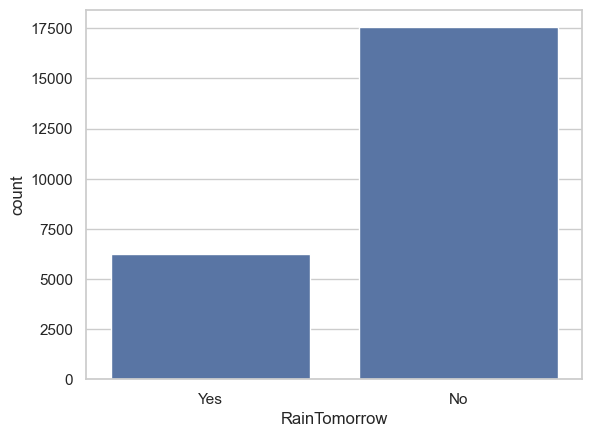

In [10]:
sns.set(style="whitegrid")
sns.countplot(x=july_data.RainTomorrow)
plt.show()

In [11]:
july_data['RainTomorrow']=july_data['RainTomorrow'].map({'Yes':1,'No':0})
july_data['RainToday']=july_data['RainToday'].map({'Yes':1,'No':0})
     

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24352\1259302867.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  july_data['RainTomorrow']=july_data['RainTomorrow'].map({'Yes':1,'No':0})
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_24352\1259302867.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  july_data['RainToday']=july_data['RainToday'].map({'Yes':1,'No':0})


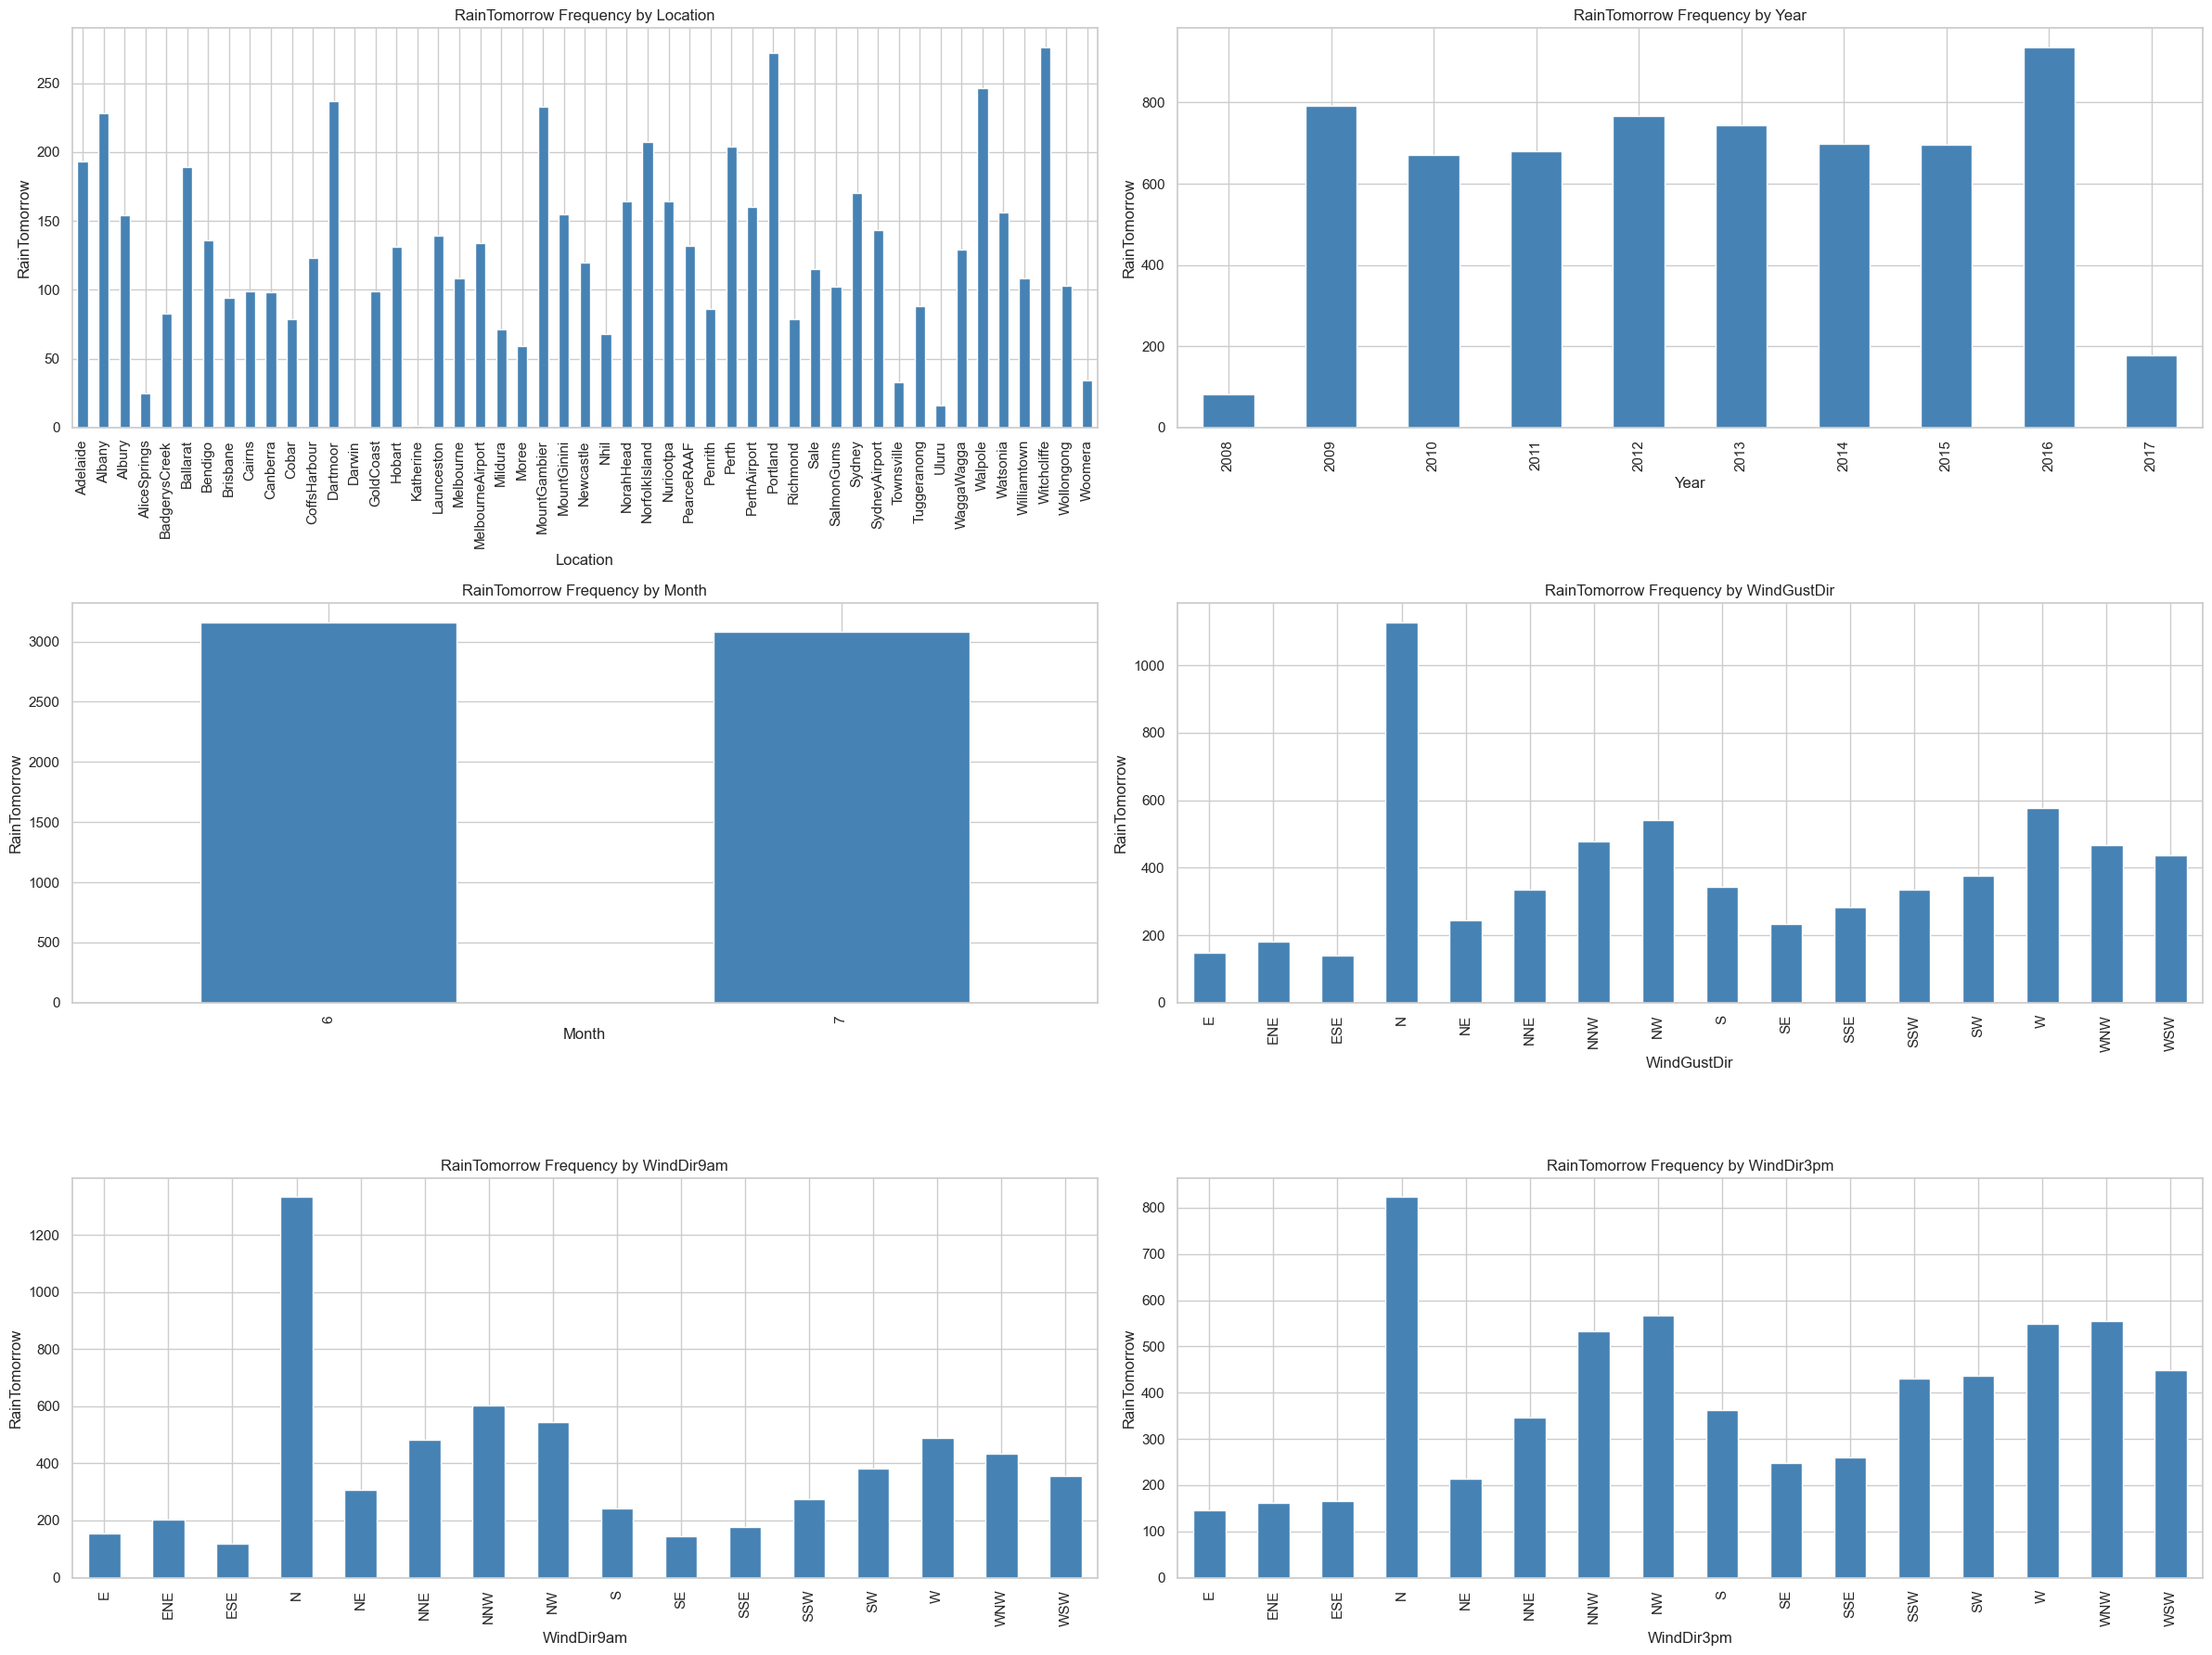

In [12]:
fig, axes = plt.subplots(3, 2, figsize=(24, 18)) 
axes = axes.flatten()  

july_data.groupby('Location')['RainTomorrow'].sum().plot(
    kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('RainTomorrow Frequency by Location')
axes[0].set_xlabel('Location')
axes[0].set_ylabel('RainTomorrow')
axes[0].tick_params(axis='x', rotation=90)

july_data.groupby('year')['RainTomorrow'].sum().plot(
    kind='bar', color='steelblue', ax=axes[1])
axes[1].set_title('RainTomorrow Frequency by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('RainTomorrow')
axes[1].tick_params(axis='x', rotation=90)


july_data.groupby('month')['RainTomorrow'].sum().plot(
    kind='bar', color='steelblue', ax=axes[2])
axes[2].set_title('RainTomorrow Frequency by Month')
axes[2].set_xlabel('Month')
axes[2].set_ylabel('RainTomorrow')
axes[2].tick_params(axis='x', rotation=90)


july_data.groupby('WindGustDir')['RainTomorrow'].sum().plot(
    kind='bar', color='steelblue', ax=axes[3])
axes[3].set_title('RainTomorrow Frequency by WindGustDir')
axes[3].set_xlabel('WindGustDir')
axes[3].set_ylabel('RainTomorrow')
axes[3].tick_params(axis='x', rotation=90)

july_data.groupby('WindDir9am')['RainTomorrow'].sum().plot(
    kind='bar', color='steelblue', ax=axes[4])
axes[4].set_title('RainTomorrow Frequency by WindDir9am')
axes[4].set_xlabel('WindDir9am')
axes[4].set_ylabel('RainTomorrow')
axes[4].tick_params(axis='x', rotation=90)

july_data.groupby('WindDir3pm')['RainTomorrow'].sum().plot(
    kind='bar', color='steelblue', ax=axes[5])
axes[5].set_title('RainTomorrow Frequency by WindDir3pm')
axes[5].set_xlabel('WindDir3pm')
axes[5].set_ylabel('RainTomorrow')
axes[5].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


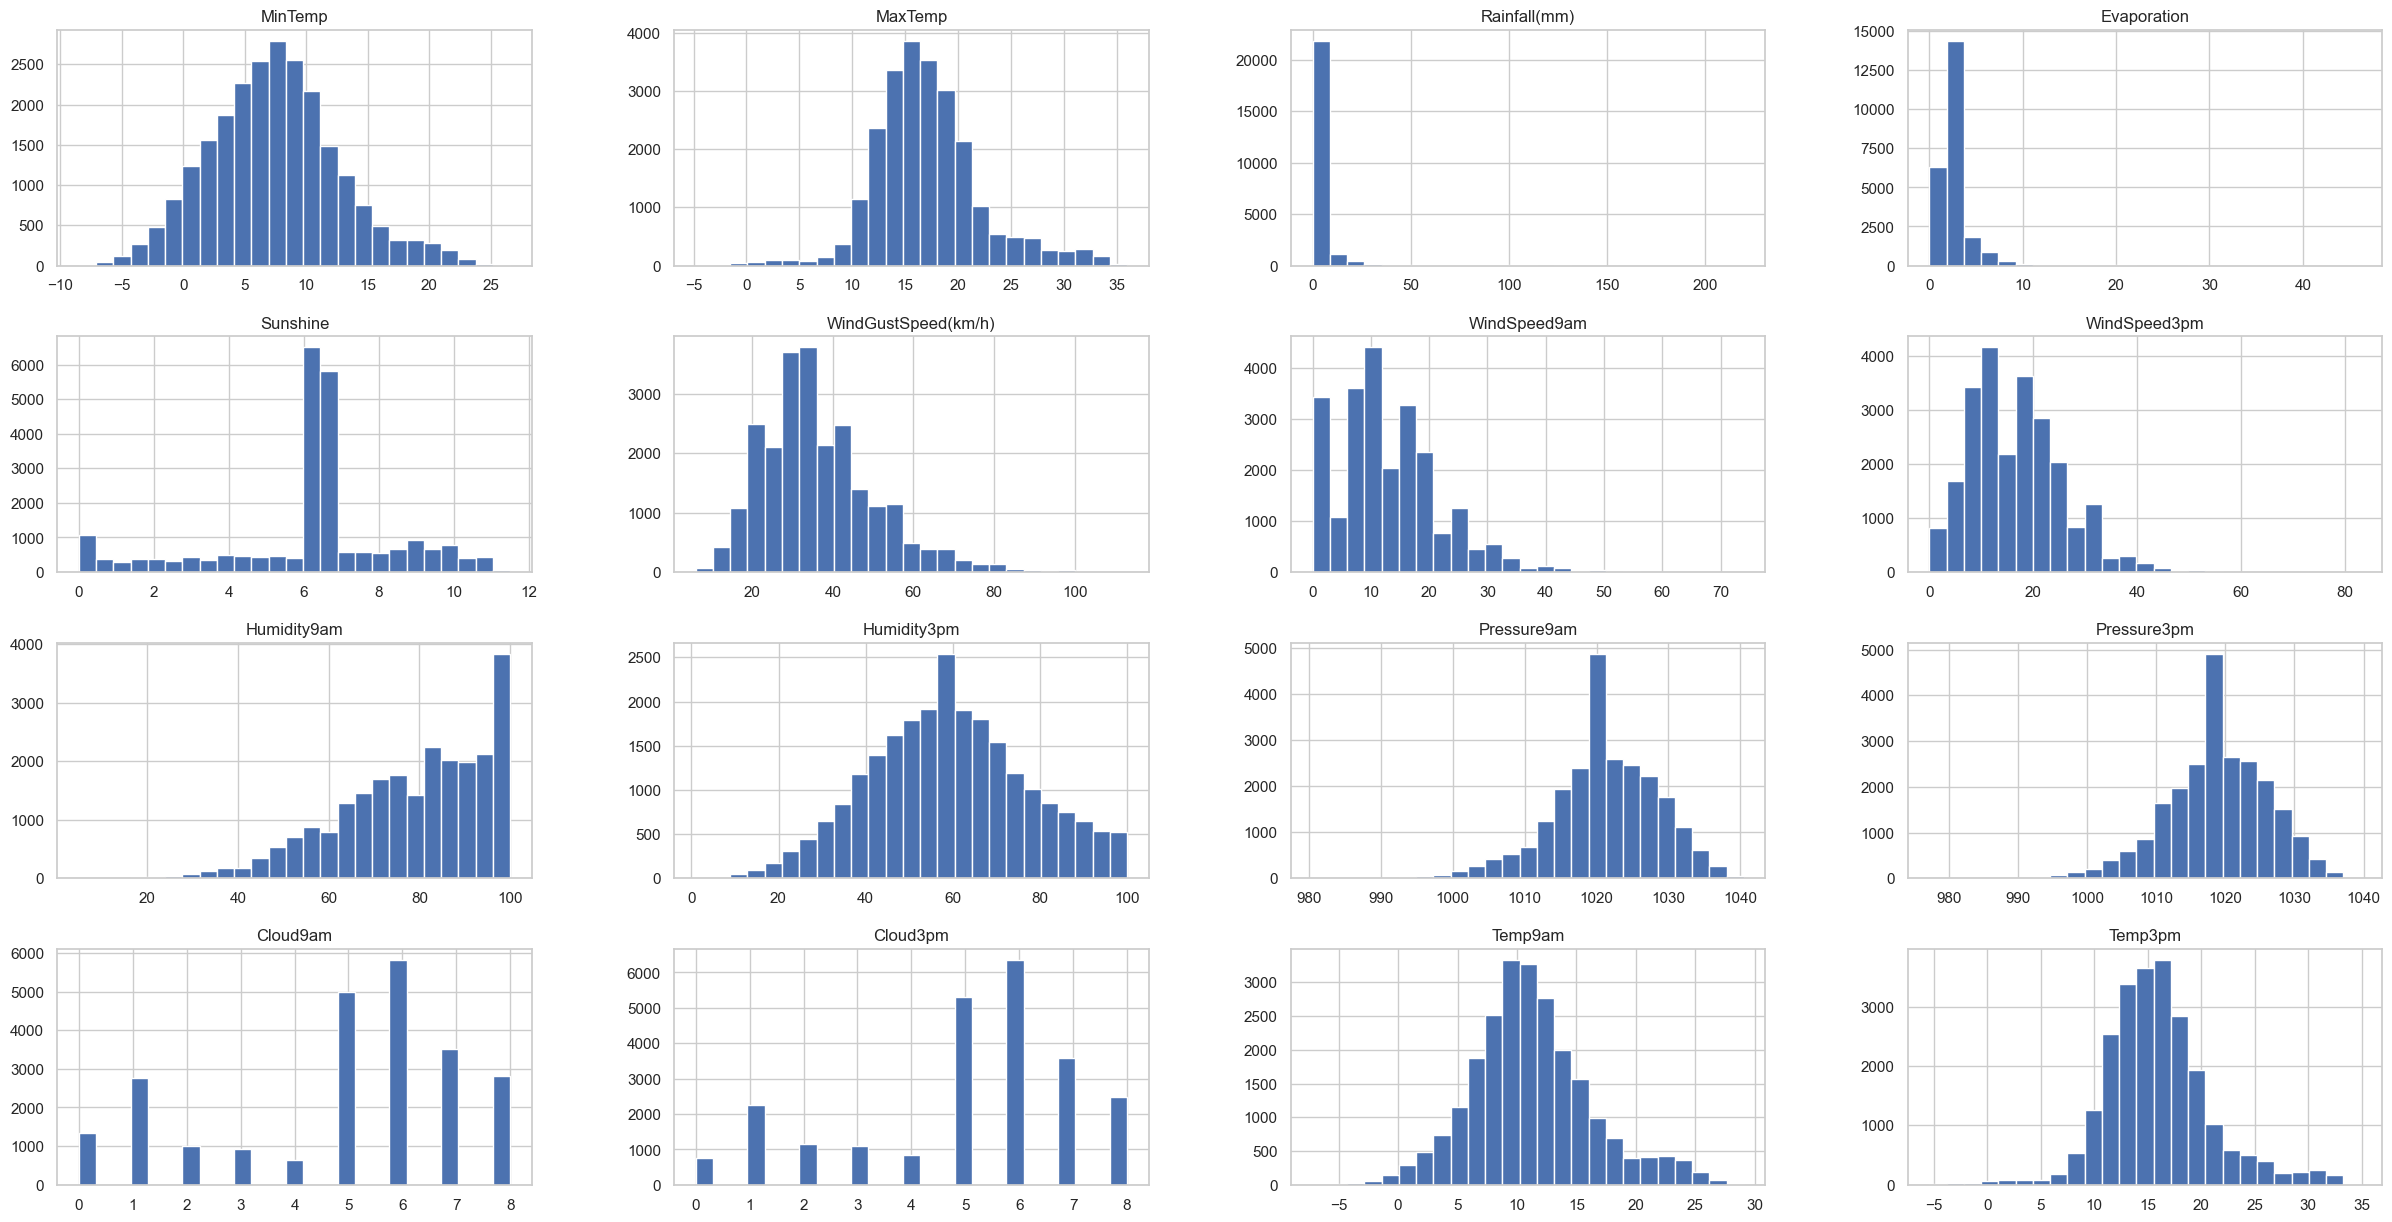

In [13]:
column_names = list(july_data.select_dtypes(include=[np.number]).drop(['year', 'month','day', 'RainToday','RainTomorrow'],axis=1).columns)
ax_count = 0
july_data.hist(column = column_names, figsize=(30, 15), bins=25)  
plt.show() 

<Axes: >

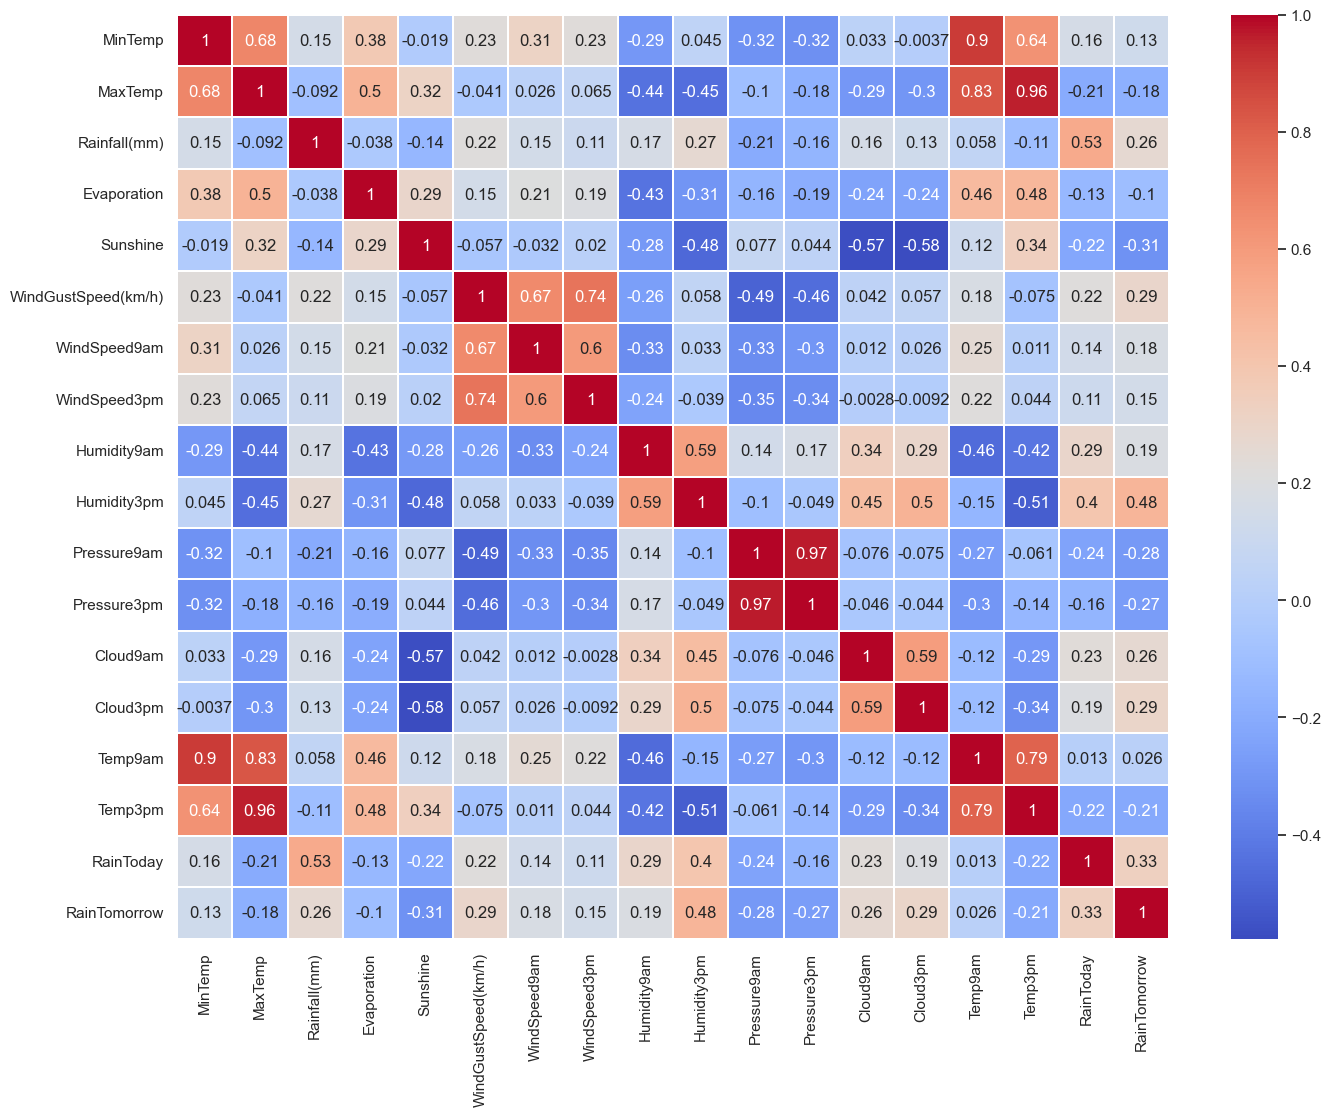

In [14]:
fig, ax = plt.subplots(figsize=(16,12))  
sns.heatmap(july_data.select_dtypes(include=[np.number]).drop(['year','month','day'],axis=1).corr(),annot=True,linewidths=0.2,ax=ax,cmap='coolwarm')

In [15]:
daily_clim = july_data.groupby('day')['RainToday'].agg(['mean','count'])
daily_clim['pct'] = daily_clim['mean']*100
avg_pct = daily_clim['pct'].mean()

fig1 = go.Figure()

fig1.add_trace(go.Bar(
    x=daily_clim.index,
    y=daily_clim['pct'],
    name='% of days with rain',
    marker_color='steelblue'
))

fig1.add_trace(go.Scatter(
    x=daily_clim.index,
    y=[avg_pct]*len(daily_clim.index),
    mode='lines',
    line=dict(color='red', dash='dash'),
    name=f"July avg: {avg_pct:.1f}%"
))

fig1.update_layout(
    title='Rain in July over the years',
    xaxis_title='Day of July',
    yaxis_title='% of location-days with rain (2009-2016)',
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    height=500
)

fig1.show()


In [16]:
june = july_data[(july_data['month']==6) & (july_data['day']<=25)]

june_stats = june.groupby('year').agg(
    rain_day_pct=('RainToday','mean'),
    avg_rainfall=('Rainfall(mm)','mean'),
    avg_humidity3pm=('Humidity3pm','mean'),
    avg_pressure3pm=('Pressure3pm','mean'),
    n=('RainToday','size')#location is calculated in size
)
june_stats['rain_day_pct'] *= 100
june_stats.round(2)

,rain_day_pct,avg_rainfall,avg_humidity3pm,avg_pressure3pm,n
year,,,,,
2008,34.00,2.98,64.28,1022.99,50
2009,30.47,2.82,61.71,1016.71,1129
2010,24.57,2.02,59.54,1021.07,1058
2011,26.19,2.62,57.37,1017.63,1092
2012,31.65,3.52,60.56,1017.61,1106
2013,25.51,2.99,62.03,1018.07,1184
2014,26.26,2.39,62.04,1019.12,1169
2015,25.28,2.16,60.10,1020.94,1171
2016,35.16,5.19,64.18,1015.60,1203


In [17]:
features = ['rain_day_pct','avg_rainfall','avg_humidity3pm','avg_pressure3pm']

hist = june_stats.drop(index=2017)[features]
stats_2017 = june_stats.loc[2017, features]

mu, sigma = hist.mean(), hist.std()

#standridze Z-score:standard results across feats
z_hist = (hist - mu) / sigma
z_2017 = (stats_2017 - mu) / sigma
#eqlid dist smaller dist = more similarty most similar is 2010
dist = ((z_hist - z_2017)**2).sum(axis=1).pow(0.5).sort_values()
print("Distances to June 2017:\n", dist.round(3))
#weighted makes those years more usable for julypct
weights = (1 / (dist + 0.15))
weights /= weights.sum()
print("\nAnalog weights:\n", weights.round(3))


Distances to June 2017:
 year
2010    2.570
2015    2.832
2011    3.640
2014    3.735
2013    3.962
2009    5.022
2012    5.100
2008    5.562
2016    7.349
dtype: float64

Analog weights:
 year
2010    0.170
2015    0.155
2011    0.122
2014    0.119
2013    0.113
2009    0.090
2012    0.088
2008    0.081
2016    0.062
dtype: float64


In [18]:
july_rain_pct = july_data.groupby('year')['RainToday'].mean()*100
merged = pd.DataFrame({'june_rain_pct': june_stats['rain_day_pct'], 'july_rain_pct': july_rain_pct}).dropna()
merged = merged[merged.index != 2017]
print(merged)

corr = merged['june_rain_pct'].corr(merged['july_rain_pct'])
print("Correlation between June rain% and following July rain% (2009-2016):", round(corr,3))

      june_rain_pct  july_rain_pct
year                              
2008      34.000000      28.859060
2009      30.469442      29.080334
2010      24.574669      25.533537
2011      26.190476      25.739645
2012      31.645570      28.856826
2013      25.506757      26.368330
2014      26.261762      25.323993
2015      25.277541      24.771609
2016      35.162095      31.708149
Correlation between June rain% and following July rain% (2009-2016): 0.942


In [19]:
#creating a pivot to store julys data(percentages)
pivot = july_data.groupby(['year','day'])['RainToday'].mean().unstack('year') * 100

weighted_daily = (pivot * weights).sum(axis=1)#weighted avg
plain_avg_daily = pivot.mean(axis=1)#non weighted avg



result = pd.DataFrame({
    'plain_rain_%': plain_avg_daily.round(1),
    'analog_weighted_%': weighted_daily.round(1)
})
#scalling factor from 0 to 100% 
result['final_estimate_%'] = result['analog_weighted_%'].clip(0,100).round(1)

print("\nFinal July 2017 average estimate:", round(result['final_estimate_%'].mean(),1), "%")

result.to_csv('july2017_final.csv')
result


Final July 2017 average estimate: 26.8 %


,plain_rain_%,analog_weighted_%,final_estimate_%
day,,,
1,29.3,31.4,31.4
2,24.0,26.2,26.2
3,27.4,28.6,28.6
4,24.1,23.1,23.1
5,28.1,28.6,28.6
6,26.7,25.7,25.7
7,25.4,24.7,24.7
8,25.1,23.6,23.6
9,25.2,23.9,23.9


In [ ]:
numeric_cols = [
    'MinTemp','MaxTemp','Rainfall(mm)','Evaporation','Sunshine',
    'WindGustSpeed(km/h)','WindSpeed9am','WindSpeed3pm',
    'Humidity9am','Humidity3pm','Pressure9am','Pressure3pm',
    'Cloud9am','Cloud3pm','Temp9am','Temp3pm'
]
cat_cols = ['WindGustDir','WindDir9am','WindDir3pm']


hist = july_data[july_data['year'] != 2017]
#function finds expected values for the cols and fils them based on history for each col
def old_value(loc, month, day, col, rain_flag=None):
    """Return historical mean/mode for given location/date/column, 
       preferring same RainToday outcome when possible."""
    subset = hist[(hist['Location'] == loc) & (hist['month'] == month) & (hist['day'] == day)]
    
  
    if rain_flag is not None:
        narrowed = subset[subset['RainToday'] == rain_flag]
        if not narrowed.empty:
            subset = narrowed
    
   
    if subset.empty:
        subset = hist[(hist['Location'] == loc) & (hist['month'] == month)]
    if subset.empty:
        subset = hist[hist['Location'] == loc]
    if subset.empty:
        subset = hist
    
    return subset[col].mode().iloc[0] if col in cat_cols else subset[col].mean()


#generate the days
np.random.seed(42)
extra_days = [(6, d) for d in range(26, 31)] + [(7, d) for d in range(1, 32)]
locations = july_data['Location'].unique()
day_prob = result['final_estimate_%'] / 100

#for each new day added find if it will rain or not based on percantages pulled in the results
new_rows = []
for loc in locations:
    rain_draws = [np.random.rand() < day_prob.loc[day] for (_, day) in extra_days]
    for i, (month, day) in enumerate(extra_days):
        rain_today = int(rain_draws[i])
        rain_tomorrow = int(rain_draws[i+1]) if i+1 < len(rain_draws) else np.nan

        row = {
            'Location': loc, 'year': 2017, 'month': month, 'day': day,
            'RainToday': rain_today, 'RainTomorrow': rain_tomorrow,
        }
       
        row.update({col: old_value(loc, month, day, col, rain_today) for col in numeric_cols})
        row.update({col: old_value(loc, month, day, col) for col in cat_cols})
        
        new_rows.append(row)

#creation of the df for the new
new_data = pd.DataFrame(new_rows).reindex(columns=july_data.columns, fill_value=np.nan)


for loc in locations:
    june25 = (july_data['Location']==loc) & (july_data['year']==2017) & (july_data['month']==6) & (july_data['day']==25)
    june26_val = new_data.loc[(new_data['Location']==loc) & (new_data['month']==6) & (new_data['day']==26), 'RainToday']
    if june25.any() and not june26_val.empty:
        july_data.loc[june25, 'RainTomorrow'] = june26_val.values[0]

#adding the new days to the old dataset
july_data = pd.concat([july_data, new_data], ignore_index=True)
july_data = july_data.sort_values(['Location','year','month','day']).reset_index(drop=True)

print(july_data.tail())


      Location  MinTemp    MaxTemp  Rainfall(mm)  Evaporation  Sunshine  \
25550  Woomera    4.850  18.200000         0.000     4.500000  8.387500   
25551  Woomera    5.950  19.187500         0.000     4.400000  6.912500   
25552  Woomera    6.800  19.142857         0.000     5.057143  7.957143   
25553  Woomera    7.475  19.812500         0.125     3.925000  7.525000   
25554  Woomera    7.025  20.487500         0.050     3.800000  7.087500   

      WindGustDir  WindGustSpeed(km/h) WindDir9am WindDir3pm  ...  \
25550           N            40.625000          N          N  ...   
25551           N            33.375000        ESE          N  ...   
25552           N            40.428571        NNE          N  ...   
25553           N            40.000000          N        WNW  ...   
25554           N            38.625000        ESE          W  ...   

       Pressure3pm  Cloud9am  Cloud3pm    Temp9am    Temp3pm  RainToday  \
25550  1023.650882  2.625000  3.375000   9.925000  17.26440

In [25]:
print(july_data.loc[(july_data['year']==2017)&(july_data['month']==6),['RainTomorrow']].value_counts())
print(july_data.loc[(july_data['year']==2017)&(july_data['month']==7),['RainTomorrow']].value_counts())

RainTomorrow
0.0             1160
1.0              257
Name: count, dtype: int64
RainTomorrow
0.0             1063
1.0              407
Name: count, dtype: int64


In [23]:
avg_val = result['final_estimate_%'].mean()

fig2= go.Figure()

fig2.add_trace(go.Bar(
    x=result.index,
    y=result['final_estimate_%'],
    marker_color='blue',
    name='Daily estimate'
))

fig2.add_trace(go.Scatter(
    x=result.index,
    y=[avg_val]*len(result.index),
    mode='lines',
    line=dict(color='red', dash='dash'),
    name=f"July 2017 avg: {avg_val:.1f}%"
))

fig2.update_layout(
    title='July 2017 daily rain probability estimate ',
    xaxis_title='Day of July',
    yaxis_title='Estimated chance of rain (%)',
    xaxis=dict(tickmode='linear', tick0=1, dtick=1),
    height=500
)

fig2.show()

fig3 = px.line(
    result,
    x=result.index,
    y=['plain_rain_%','analog_weighted_%','final_estimate_%'],
    title="Rain % in July 2017",
    labels={'value':'Rain probability (%)','day':'Day of July'}
)

colors = ['blue','green','red']
for i, trace in enumerate(fig3.data):
    trace.line.color = colors[i]
    trace.line.width = 3
    trace.mode = 'lines+markers'

fig3.update_layout(title_font_size=17)
fig3.update_xaxes(rangeslider_visible=True)

fig3.show()


In [24]:
from dash import Dash, html, dcc, dash_table
import dash_bootstrap_components as dbc


app = Dash(__name__, external_stylesheets=[dbc.themes.DARKLY])

app.layout = dbc.Container([
   
    dbc.Row([
        dbc.Col(
            html.Div([
                dbc.Badge("Moaz Elsaeed", color="primary", className="mx-2 p-3 fs-4"),
                dbc.Badge("Abdulrahman Ateia", color="primary", className="mx-2 p-3 fs-4"),
                dbc.Badge("Youssef Tamer", color="primary", className="mx-2 p-3 fs-4"),
                dbc.Badge("Mahmoud_Abdelghany", color="primary", className="mx-2 p-3 fs-4"),
                dbc.Badge("Mostafa Mohammed", color="primary", className="mx-2 p-3 fs-4"),
            ], className="text-center mb-5")
        , width=12)
    ]),

   
    dbc.Row([
        dbc.Col(
            dash_table.DataTable(
                data=july_data.to_dict("records"),
                page_size=15,
                style_table={"overflowX": "auto"},
                style_cell={"textAlign": "center", "backgroundColor": "#222", "color": "white"}
            ), width=12
        )
    ], className="mb-4"),


    dbc.Row([
        dbc.Col(
            dbc.Card([
                dbc.CardHeader("Figure 1", className="bg-primary text-white"),
                dbc.CardBody(dcc.Graph(figure=fig1))
            ], className="shadow mb-4"), width=12
        )
    ]),
    dbc.Row([
        dbc.Col(
            dbc.Card([
                dbc.CardHeader("Figure 2", className="bg-success text-white"),
                dbc.CardBody(dcc.Graph(figure=fig2))
            ], className="shadow mb-4"), width=12
        )
    ]),
    dbc.Row([
        dbc.Col(
            dbc.Card([
                dbc.CardHeader("Figure 3", className="bg-danger text-white"),
                dbc.CardBody(dcc.Graph(figure=fig3))
            ], className="shadow mb-4"), width=12
        )
    ])
], fluid=True, className="bg-dark text-light")

if __name__ == "__main__":
    app.run(debug=True, port=8020)


Traceback (most recent call last):
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\plotly_cloud\_devtool_publish_rpc.py", line 169, in handle_operation
    return await method(data)
           ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\plotly_cloud\_devtool_publish_rpc.py", line 184, in initialize
    project_path = self.get_project_path()
  File "C:\Users\Lenovo\AppData\Roaming\Python\Python313\site-packages\plotly_cloud\_devtool_publish_rpc.py", line 66, in get_project_path
    return os.path.dirname(str(app_module.__file__))
                               ^^^^^^^^^^^^^^^^^^^
AttributeError: module '__main__' has no attribute '__file__'. Did you mean: '__name__'?


Visit http://127.0.0.1:8020/ in your web browser. You should see an app that looks like the one above.